In [ ]:
!pip install -q \
    "pandas==2.2.3" \
    "scanpy==1.11.5" \
    "anndata==0.12.19" \
    "gseapy==1.3.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.1/176.1 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.7/689.7 kB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 138.0 MB/s eta 0:00:00


In [ ]:
# Import Scanpy for single-cell RNA-seq analysis
import scanpy as sc

# Import AnnData for handling .h5ad files
import anndata as ad

# Import NumPy for numerical operations
import numpy as np

# Import pandas for handling metadata and tables
import pandas as pd

# Import Matplotlib for visualization
import matplotlib.pyplot as plt


# Configure Scanpy output
sc.settings.verbosity = 3

sc.settings.set_figure_params(
    dpi=120,
    facecolor="white",
    frameon=False
)


# Record the software versions used for this analysis
print("Scanpy:", sc.__version__)
print("AnnData:", ad.__version__)
print("Pandas:", pd.__version__)

Scanpy: 1.11.5
AnnData: 0.12.19
Pandas: 2.2.3


/tmp/ipykernel_6526/2967680814.py:28: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("Scanpy:", sc.__version__)
/tmp/ipykernel_6526/2967680814.py:29: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  print("AnnData:", ad.__version__)


In [3]:
# Mount Google Drive so the processed .h5ad files
# can be accessed from persistent storage.
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
# Load the dataset produced at the end of Step 8.4.
# This contains PCA, neighbors, UMAP, and Leiden clustering.

adata = sc.read_h5ad(
    "/content/drive/MyDrive/sc-project3-IFN-I/clustering_res1.0.h5ad"
)

print(adata)

print(f"Cells: {adata.n_obs:,}")
print(f"Genes: {adata.n_vars:,}")

AnnData object with n_obs × n_vars = 94513 × 2500
    obs: 'sample', 'donor_type', 'sample_batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes', 'leiden_res_1.0'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'donor_type_colors', 'hvg', 'leiden_res_1.0', 'leiden_res_1.0_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'
Cells: 94,513
Genes: 2,500


In [5]:
# Confirm that the Leiden cluster assignments from Step 8.4
# are present in the cell metadata.

print(adata.obs.columns.tolist())

['sample', 'donor_type', 'sample_batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes', 'leiden_res_1.0']


In [6]:
# Check whether the full normalized/log-transformed expression
# matrix was preserved in adata.raw during Step 8.3.

print(adata.raw)

Raw AnnData with n_obs × n_vars = 94513 × 31054
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'


In [7]:
# Define the six core interferon-stimulated protein (ISP) genes
# identified by the publication as the IRC signature.

isg_signature = [
    "BST2",
    "EIF2AK2",
    "ISG15",
    "MX1",
    "IFIT3",
    "IRF7"
]

In [8]:
# Check which IRC genes are present in the full normalized
# expression matrix stored in adata.raw.

valid_isgs = [
    gene for gene in isg_signature
    if gene in adata.raw.var_names
]

print(
    f"Calculating IRC score using "
    f"{len(valid_isgs)}/{len(isg_signature)} genes:"
)

print(valid_isgs)

Calculating IRC score using 6/6 genes:
['BST2', 'EIF2AK2', 'ISG15', 'MX1', 'IFIT3', 'IRF7']


In [9]:
# Calculate the Interferon Response Capacity (IRC) module score.
#
# use_raw=True ensures that all six signature genes are taken
# from the full normalized/log-transformed expression matrix
# rather than only the 2,500 HVGs.

sc.tl.score_genes(
    adata,
    gene_list=valid_isgs,
    score_name="IRC_score",
    use_raw=True
)

print("IRC score calculated successfully.")

computing score 'IRC_score'
    finished: added
    'IRC_score', score of gene set (adata.obs).
    250 total control genes are used. (0:00:04)
IRC score calculated successfully.


In [10]:
adata.obs["IRC_score"]

,IRC_score
AAACAGCCAAACTCAT-1-HD1,0.391114
AAACAGCCAATTAACC-1-HD1,-0.223230
AAACAGCCACAATACT-1-HD1,-0.066829
AAACAGCCACTAAGCC-1-HD1,-0.061091
AAACAGCCAGATAGAC-1-HD1,-0.177281
...,...
TTTGTTGGTCCGTAGG-1-P8,-0.259729
TTTGTTGGTCCTTAGT-1-P8,0.009150
TTTGTTGGTTAACAGT-1-P8,-0.051680
TTTGTTGGTTGCAATG-1-P8,-0.058475


In [11]:
# Examine the distribution of IRC scores across all cells.

print(adata.obs["IRC_score"].describe())

count    94513.000000
mean        -0.019505
std          0.230081
min         -0.387685
25%         -0.199395
50%         -0.061560
75%          0.089361
max          2.078771
Name: IRC_score, dtype: float64


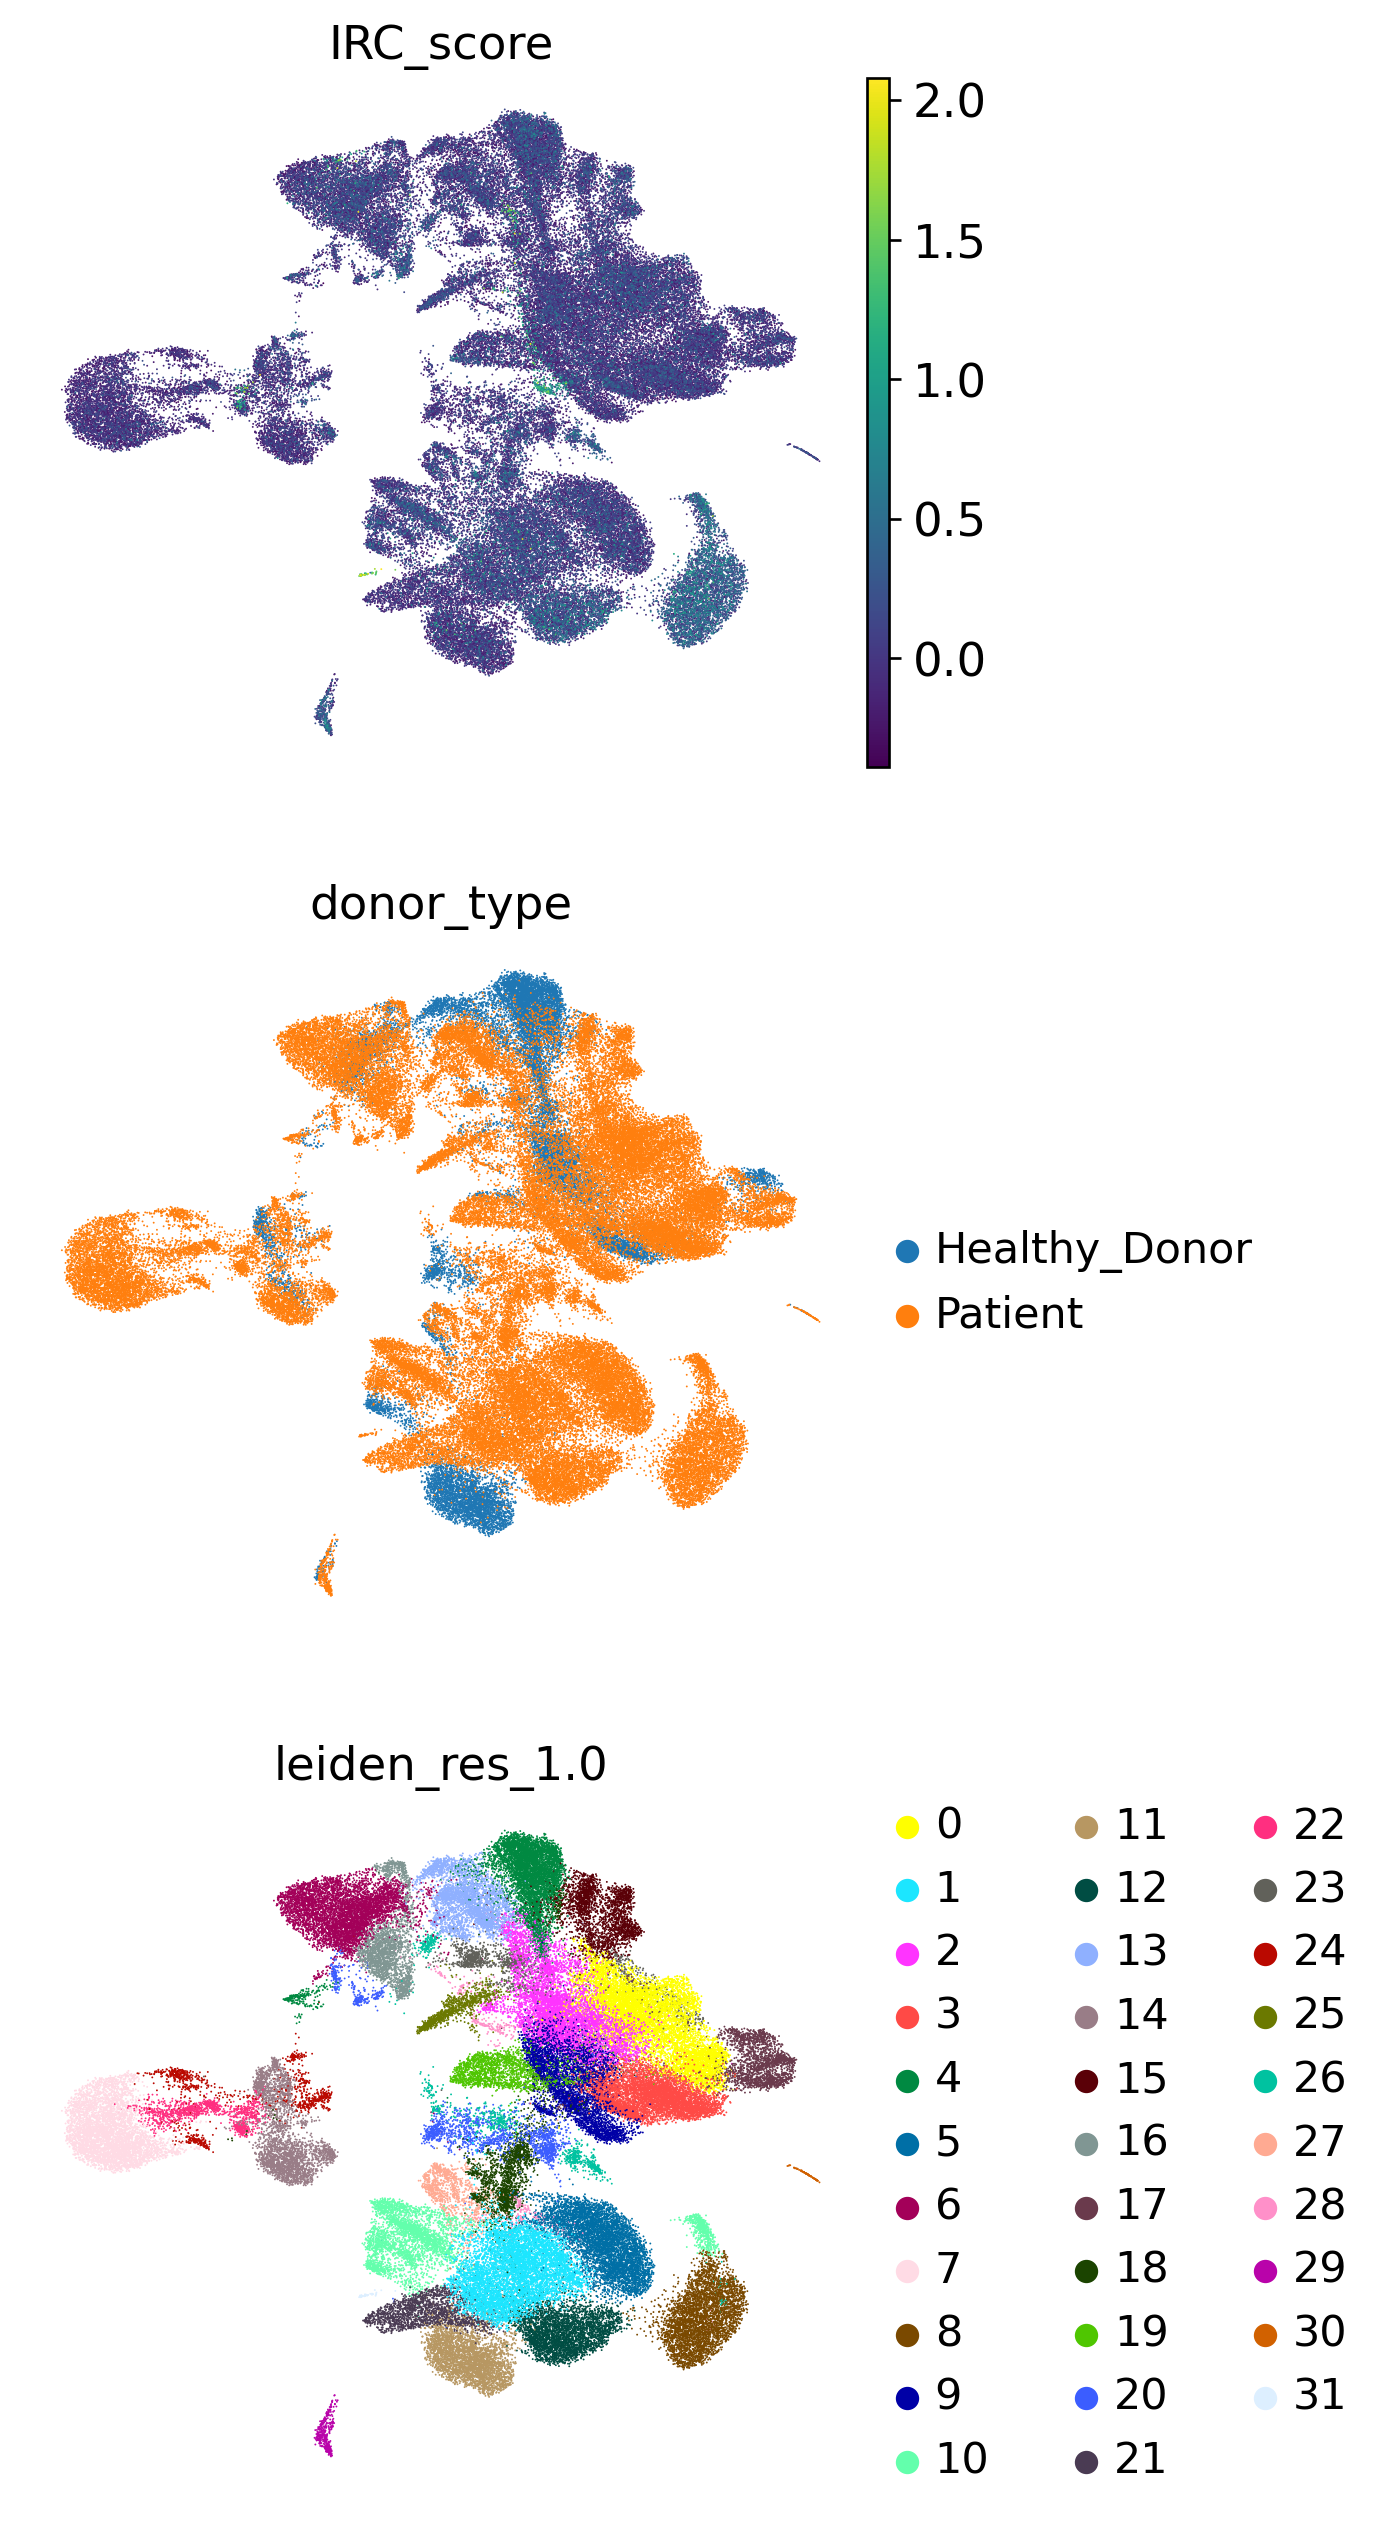

In [13]:
# Visualize the IRC score across the existing UMAP.
#
# The UMAP itself is unchanged; we are simply coloring
# cells according to their IRC score.

sc.pl.umap(
    adata,
    color=[
        "IRC_score",
        "donor_type",
        "leiden_res_1.0"
    ],
    cmap="viridis",
    ncols=1
)

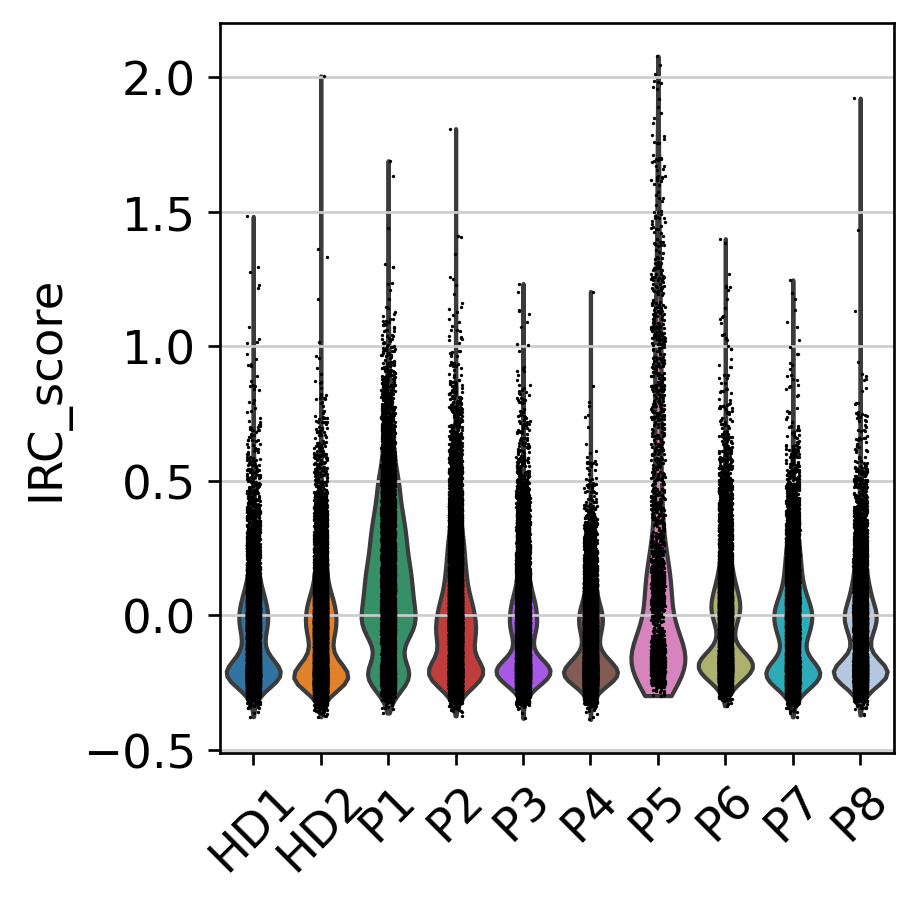

In [14]:
# Compare the distribution of IRC scores between samples.
# Each violin represents the distribution of IRC scores
# among cells belonging to that sample.

sc.pl.violin(
    adata,
    keys="IRC_score",
    groupby="sample",
    rotation=45
)

In [15]:
# Save the AnnData object containing the IRC score.
#
# The IRC score is stored in:
# adata.obs["IRC_score"]

adata.write_h5ad(
    "/content/drive/MyDrive/sc-project3-IFN-I/ifn_irc_scored.h5ad"
)

print("8.6 IRC-scored dataset saved successfully.")

8.6 IRC-scored dataset saved successfully.


In [16]:
# Select only cells from patients.
#
# This removes non-patient/donor cells from the analysis
# so that IRC-High vs IRC-Low stratification is performed
# specifically within the patient population.

patient_adata = adata[
    adata.obs["donor_type"] == "Patient"
].copy()


# Check how many patient cells remain
print(
    f"Patient cells: {patient_adata.n_obs:,}"
)

Patient cells: 75,337


In [17]:
# Calculate the median IRC score among patient cells.
#
# The median will be used as the cutoff to divide patient
# cells into two groups with relatively high or low
# interferon-response capacity.

median_score = patient_adata.obs["IRC_score"].median()

print(f"Median IRC score: {median_score:.4f}")

Median IRC score: -0.0532


In [18]:
# Assign each patient cell to an IRC group.
#
# Cells with IRC scores greater than or equal to the median
# are classified as IRC_High.
#
# Cells below the median are classified as IRC_Low.

patient_adata.obs["IRC_group"] = np.where(
    patient_adata.obs["IRC_score"] >= median_score,
    "IRC_High",
    "IRC_Low"
)


# Count cells in each IRC group
print(
    patient_adata.obs["IRC_group"].value_counts()
)

IRC_group
IRC_High    37669
IRC_Low     37668
Name: count, dtype: int64


In [19]:
# Perform differential expression analysis between
# IRC_High and IRC_Low patient cells.
#
# The Wilcoxon rank-sum test is used to identify genes
# whose expression differs between the two IRC groups.

sc.tl.rank_genes_groups(
    patient_adata,
    groupby="IRC_group",
    method="wilcoxon"
)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:02:54)


In [20]:
# Extract the differential-expression results for
# the IRC_High group.
#
# Positive-ranked genes represent genes associated with
# higher expression in IRC_High cells.

de_df = sc.get.rank_genes_groups_df(
    patient_adata,
    group="IRC_High"
)


# Display the top 15 genes associated with IRC_High cells
print("Top upregulated genes in IRC-High patients:")
print(de_df.head(15))

Top upregulated genes in IRC-High patients:
      names      scores  logfoldchanges          pvals      pvals_adj
0   EIF2AK2  146.977325        4.070147   0.000000e+00   0.000000e+00
1       MX1   87.193130        4.308722   0.000000e+00   0.000000e+00
2      BST2   62.821815        3.392258   0.000000e+00   0.000000e+00
3    RNF213   42.278107        0.539485   0.000000e+00   0.000000e+00
4    EPSTI1   41.953979        1.074664   0.000000e+00   0.000000e+00
5     STAT1   41.552063        0.792734   0.000000e+00   0.000000e+00
6      XAF1   41.499218        1.293257   0.000000e+00   0.000000e+00
7    IFI44L   40.572445        2.006560   0.000000e+00   0.000000e+00
8    PARP14   40.249344        0.748401   0.000000e+00   0.000000e+00
9     IFI44   39.389107        1.622606   0.000000e+00   0.000000e+00
10     TYMP   38.651451        0.911188   0.000000e+00   0.000000e+00
11     AOAH   37.380299        0.692332  8.166503e-306  2.113355e-302
12     JAK2   36.620235        0.677415  1.362

One thing I want you to be careful about

Your rulebook calls this:

Patient Stratification & Differential Expression

but the actual code stratifies patient cells, not necessarily entire patients.

That's an important distinction.

This:

patient_adata = adata[
    adata.obs["donor_type"] == "Patient"
].copy()

means you're taking all cells belonging to patients and then assigning each cell to IRC-High or IRC-Low based on its individual IRC score.

So this:

IRC_High vs IRC_Low

is currently a cell-level comparison, not:

Patient 1 = IRC_High
Patient 2 = IRC_Low
Patient 3 = IRC_High
...

That's fine if it's what the publication/rulebook intends, but it's something we should explicitly recognize because it affects how the DE results should be interpreted.

In [21]:
# Save the patient subset with IRC group assignments
# and differential-expression results.
#
# The DE results themselves are stored in adata.uns,
# while IRC_group is stored in patient_adata.obs.

patient_adata.write_h5ad(
    "/content/drive/MyDrive/sc-project3-IFN-I/patient_irc_DE.h5ad"
)

# Also save the differential-expression table as a CSV
# so that it can be easily opened and shared.

de_df.to_csv(
    "/content/drive/MyDrive/sc-project3-IFN-I/IRC_High_vs_Low_DE.csv",
    index=False
)

print("Step 8.7 results saved successfully.")

Step 8.7 results saved successfully.
